# Multinomial Naive Bayes - SMS Spam Classification

This notebook implements **Multinomial Naive Bayes for text classification** using the SMS Spam Collection dataset.

The project covers:
- Exploratory Data Analysis (EDA)
- Text preprocessing
- Train/test splitting
- Building a vocabulary from training data
- Converting text into word-count vectors
- Calculating class priors and word probabilities
- Laplace smoothing
- From-scratch Multinomial Naive Bayes using Python and NumPy
- Model evaluation
- Comparison with Scikit-learn
- Prediction agreement, complexity, and applications

The main goal is to understand how Multinomial Naive Bayes works internally rather than treating it as a black-box algorithm.

In [33]:
# Import libraries required for data handling, visualization, and numerical operations.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the Dataset

The SMS Spam Collection contains text messages labelled as:
- **ham (0):** normal/non-spam message
- **spam (1):** unwanted or promotional message

Each row contains a class label and the corresponding SMS text.

In [34]:
# Load the tab-separated SMS dataset and assign readable column names.
df = pd.read_csv(
    "../dataset/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

In [35]:
# Display a few records to verify that the dataset loaded correctly.
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [36]:
# Check the number of rows and columns in the dataset.
df.shape

(5572, 2)

In [37]:
# Inspect column data types and non-null counts.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


## 2. Initial Dataset Inspection

We first inspect the class distribution to understand whether the dataset is balanced or imbalanced.

In [38]:
# Count how many messages belong to each class.
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

## 3. Data Quality Check

We check for missing values and duplicate messages before continuing with the analysis.

In [39]:
# Check whether any values are missing.
df.isnull().sum()

label      0
message    0
dtype: int64

In [40]:
# Count duplicate rows before removing them.
df.duplicated().sum()

np.int64(403)

In [41]:
# Remove duplicate messages and reset the row index.
df = df.drop_duplicates().reset_index(drop=True)

In [42]:
# Confirm that duplicate rows have been removed.
df.duplicated().sum()

np.int64(0)

In [43]:
# Recheck the class distribution after duplicate removal.
df["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

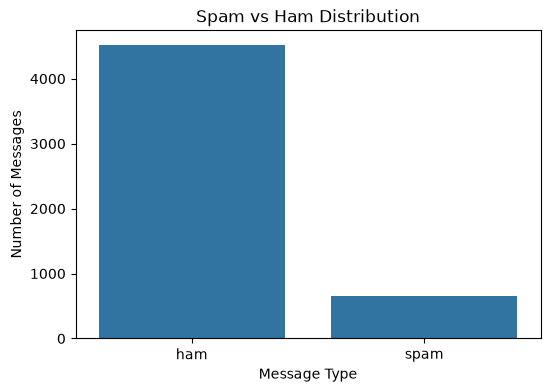

In [44]:
# Visualize the number of Ham and Spam messages.
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="label")

plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.show()

## 4. Exploratory Data Analysis: Message Length

Message length is created only for **EDA**. It helps us understand whether spam and ham messages tend to differ in length.

It is **not used as the feature input** for the final Multinomial Naive Bayes model. The actual model uses word-frequency information.

In [45]:
# Calculate SMS length for exploratory analysis only.
df["message_length"] = df["message"].str.len()

In [46]:
# Compare message-length statistics between Ham and Spam.
df.groupby("label")["message_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


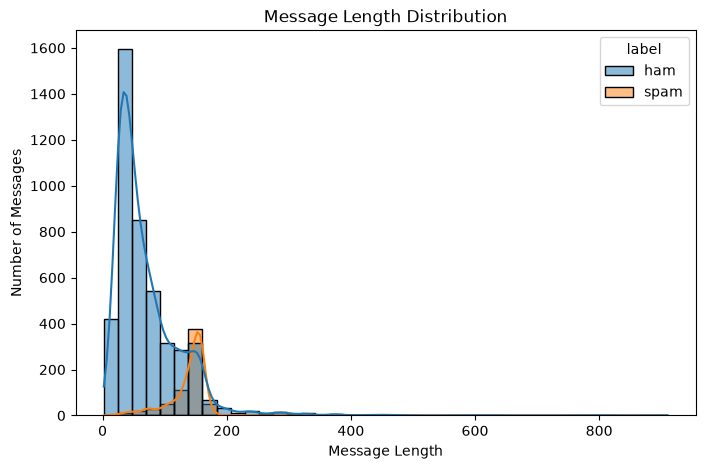

In [47]:
# Visualize the distribution of message lengths for both classes.
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=40,
    kde=True
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Number of Messages")
plt.show()

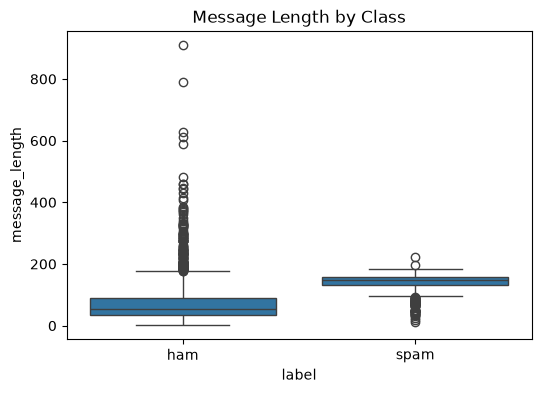

In [48]:
# Use a boxplot to inspect message-length spread and possible outliers.
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="label",
    y="message_length"
)

plt.title("Message Length by Class")
plt.show()

## 5. Label Encoding

Machine-learning calculations require numerical class labels.

We map:
- `ham → 0`
- `spam → 1`

In [49]:
# Convert text labels into numerical class labels.
df["label"] = df["label"].map({"ham": 0, "spam": 1})

In [50]:
# Verify the encoded class distribution.
df["label"].value_counts()

label
0    4516
1     653
Name: count, dtype: int64

## 6. Train/Test Split

The dataset is divided into training and testing sets.

The model learns vocabulary and word probabilities from the **training data only**. The test set is kept separate for final evaluation.

In [51]:
# Split data into training and testing sets while preserving class proportions.
from sklearn.model_selection import train_test_split
X = df["message"]
Y = df["label"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)



In [52]:
# Display the number of training and testing messages.
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 4135
Test set size: 1034


## 7. Text Preprocessing

The SMS text is simplified before converting it into word counts.

The preprocessing:
1. Converts text to lowercase.
2. Removes characters other than lowercase English letters and spaces.

This keeps the implementation simple and makes equivalent words such as `Free` and `free` identical.

In [53]:
# Define a simple text-cleaning function for the SMS messages.
import re

def class_text(text):
    text=text.lower()
    text=re.sub(r"[^a-z ]", "",text)
    return text

In [54]:
# Test the preprocessing function on one example message.
class_text("	U dun say so early hor... U c already then say... ")

'u dun say so early hor u c already then say '

In [55]:
# Apply the same preprocessing to training and test messages.
X_train_clean = X_train.apply(class_text)
X_test_clean = X_test.apply(class_text)

## 8. Build the Vocabulary

The vocabulary contains the unique words found in the **training messages**.

Building it only from training data prevents information from the test set from influencing the model.

In [56]:
# Build the vocabulary using words from training messages only.
vocabulary = set()
for message in X_train_clean:
    words = message.split()
    vocabulary.update(words)

vocabulary = sorted(vocabulary)

print(f"Vocabulary size: {len(vocabulary)}")
print(f"First 20 words in vocabulary: {vocabulary[:20]}")

Vocabulary size: 7574
First 20 words in vocabulary: ['a', 'aa', 'aah', 'aaooooright', 'aathilove', 'ab', 'abdomen', 'abeg', 'aberdeen', 'abi', 'ability', 'abiola', 'able', 'abnormally', 'about', 'aboutas', 'above', 'absolutely', 'abt', 'abta']


In [57]:
# Assign a unique integer index to every vocabulary word.
word_to_index = {
    word: i for i, word in enumerate(vocabulary)
}

In [58]:
# Inspect a small portion of the word-to-index mapping.
print(list(word_to_index.items())[:20])

[('a', 0), ('aa', 1), ('aah', 2), ('aaooooright', 3), ('aathilove', 4), ('ab', 5), ('abdomen', 6), ('abeg', 7), ('aberdeen', 8), ('abi', 9), ('ability', 10), ('abiola', 11), ('able', 12), ('abnormally', 13), ('about', 14), ('aboutas', 15), ('above', 16), ('absolutely', 17), ('abt', 18), ('abta', 19)]


## 9. Convert Text into Word-Count Vectors

Each SMS is represented as a numerical vector.

For every vocabulary word, the vector stores how many times that word occurs in the message.

Example:

`free free prize`

becomes counts such as:
- `free → 2`
- `prize → 1`

This frequency representation is the key reason this model is called **Multinomial** Naive Bayes.

In [59]:
# Convert a cleaned message into a vector containing word frequencies.
def text_to_vector(text, word_to_index):
    vector = np.zeros(len(word_to_index), dtype=int)

    words = text.split()

    for word in words:
        if word in word_to_index:
            vector[word_to_index[word]] += 1

    return vector

In [60]:
# Demonstrate the vector representation for one training message.
sample = X_train_clean.iloc[0]

vector = text_to_vector(sample, word_to_index)

print("Message:", sample)
print("Vector shape:", vector.shape)
print("Non-zero values:", vector[vector > 0])

Message: tadaaaaa i am home babe are you still up 
Vector shape: (7574,)
Non-zero values: [1 1 1 1 1 1 1 1 1]


## 10. Calculate Class Prior Probabilities

The prior probability represents how common each class is in the training data.

Formula:

`P(class) = number of training messages in class / total training messages`

These priors are used together with word probabilities during prediction.

In [63]:
# Calculate the prior probability of each class from training labels.
ham_count = np.sum(Y_train==0)
spam_count = np.sum(Y_train==1)

total = len(Y_train)

prior_ham = ham_count / total
prior_spam = spam_count / total

print(f"Prior probability of ham: {prior_ham:.4f}")
print(f"Prior probability of spam: {prior_spam:.4f}")

Prior probability of ham: 0.8738
Prior probability of spam: 0.1262


## 11. Count Word Occurrences by Class

We add word counts across all training messages separately for Ham and Spam.

This gives us the total number of occurrences of every vocabulary word within each class.

In [ ]:
# Convert every training SMS into its vocabulary-based word-count vector.
# ---------------------------------------------------------
# STEP 9: Count Words for Each Class
# ---------------------------------------------------------
# First, convert every training SMS into a word-count vector.
# Each column represents one word from the vocabulary.
#
# Example:
# "free free prize"
# free  -> 2
# prize -> 1

X_train_vectors = np.array([
    text_to_vector(message, word_to_index)
    for message in X_train_clean
])

print(X_train_vectors.shape)

(4135, 7574)


In [ ]:
# Sum word occurrences separately for Ham and Spam training messages.
# Select Ham messages and add their word counts column-wise.
ham_word_counts = X_train_vectors[y_train.to_numpy() == 0].sum(axis=0)

# Select Spam messages and add their word counts column-wise.
spam_word_counts = X_train_vectors[y_train.to_numpy() == 1].sum(axis=0)

In [66]:
# Inspect a few learned word-count values for both classes.
print("Ham word counts:", ham_word_counts[:20])
print("Spam word counts:", spam_word_counts[:20])

Ham word counts: [767   1   3   1   1   0   1   1   0   2   1   6  15   1 114   1   1   1
  21   0]
Spam word counts: [247   0   0   0   0   1   0   0   1   0   0   0   0   0   5   0   0   0
   0   1]


## 12. Calculate Word Probabilities with Laplace Smoothing

For each vocabulary word, we calculate:

`P(word | class) = (word_count + alpha) / (total_words_in_class + alpha × vocabulary_size)`

Here `alpha = 1`, which is standard Laplace smoothing.

Smoothing prevents a word that was never observed in one class from receiving probability zero.

In [69]:
# Calculate smoothed P(word | class) values using Laplace smoothing.
# ---------------------------------------------------------
# STEP 10: Calculate Word Probabilities
# ---------------------------------------------------------
# We use Laplace smoothing to prevent zero probability.
#
# Formula:
# P(word | class) =
# (word_count + alpha) /
# (total_words_in_class + alpha * vocabulary_size)
#
# alpha = 1 is the standard Laplace smoothing value.

alpha = 1

# Total number of unique words in our vocabulary.
vocab_size = len(vocabulary)

# Total word occurrences in Ham and Spam messages.
ham_total_words = ham_word_counts.sum()
spam_total_words = spam_word_counts.sum()

# Calculate probability of every vocabulary word given Ham.
ham_word_prob = (
    ham_word_counts + alpha
) / (
    ham_total_words + alpha * vocab_size
)

# Calculate probability of every vocabulary word given Spam.
spam_word_prob = (
    spam_word_counts + alpha
) / (
    spam_total_words + alpha * vocab_size
)

print("Ham probabilities:", ham_word_prob[:20])
print("Spam probabilities:", spam_word_prob[:20])

Ham probabilities: [1.33263925e-02 3.47041471e-05 6.94082943e-05 3.47041471e-05
 3.47041471e-05 1.73520736e-05 3.47041471e-05 3.47041471e-05
 1.73520736e-05 5.20562207e-05 3.47041471e-05 1.21464515e-04
 2.77633177e-04 3.47041471e-05 1.99548846e-03 3.47041471e-05
 3.47041471e-05 3.47041471e-05 3.81745619e-04 1.73520736e-05]
Spam probabilities: [1.33786481e-02 5.39461617e-05 5.39461617e-05 5.39461617e-05
 5.39461617e-05 1.07892323e-04 5.39461617e-05 5.39461617e-05
 1.07892323e-04 5.39461617e-05 5.39461617e-05 5.39461617e-05
 5.39461617e-05 5.39461617e-05 3.23676970e-04 5.39461617e-05
 5.39461617e-05 5.39461617e-05 5.39461617e-05 1.07892323e-04]


## 13. Multinomial Naive Bayes: Mathematical Idea

For a document `d` and class `c`:

`P(c | d) ∝ P(c) × ∏ P(w | c)^count(w,d)`

Because multiplying many small probabilities can cause numerical underflow, the implementation uses logarithms:

`log P(c | d) = log P(c) + Σ count(w,d) × log P(w | c)`

The predicted class is the class with the largest log-probability score.

The **naive assumption** is that words are conditionally independent given the class.

## Multinomial Naive Bayes From Scratch

Multinomial Naive Bayes is commonly used for text classification
because it works with word-frequency information.

For a document d and class c:

P(c | d) ∝ P(c) × ∏ P(w | c)^count(w,d)

To avoid numerical underflow, we use the logarithmic form:

log P(c | d) = log P(c) + Σ count(w,d) × log P(w | c)

Laplace smoothing is used while calculating word probabilities
so that unseen words do not result in zero probability.

## 14. From-Scratch Model Implementation

The following class implements the Multinomial Naive Bayes calculations directly.

No ready-made Naive Bayes classifier is used for the from-scratch model.

The model learns:
- class prior probabilities
- word probabilities for each class
- Laplace smoothing controlled by `alpha`

During prediction, word counts are combined with the learned probabilities using the log-probability formula.

In [70]:
# Implement Multinomial Naive Bayes without using a ready-made classifier.
# ---------------------------------------------------------
# Multinomial Naive Bayes From Scratch
# ---------------------------------------------------------

class MultinomialNBFromScratch:

    def __init__(self, alpha=1.0):
        # alpha controls Laplace smoothing.
        # alpha=1 means standard Laplace smoothing.
        self.alpha = alpha

    def fit(self, X, y):
        # Convert input into NumPy arrays so that
        # we can perform numerical operations easily.
        X = np.asarray(X)
        y = np.asarray(y)

        # Find the unique class labels.
        # In our dataset:
        # 0 = Ham
        # 1 = Spam
        self.classes = np.unique(y)

        # Store the number of documents.
        n_samples = len(X)

        # Store the vocabulary size (number of features).
        self.n_features = X.shape[1]

        # Lists to store class priors and word probabilities.
        self.class_priors = []
        self.feature_probs = []

        # Calculate statistics separately for every class.
        for c in self.classes:

            # Select only the documents belonging to class c.
            X_c = X[y == c]

            # Calculate prior probability:
            # P(c) = Number of documents in class / Total documents
            prior = len(X_c) / n_samples

            # Count total occurrences of every word
            # within this particular class.
            word_counts = X_c.sum(axis=0)

            # Total number of words in this class.
            total_words = word_counts.sum()

            # Apply Laplace smoothing.
            #
            # P(word | class) =
            # (word_count + alpha) /
            # (total_words + alpha * vocabulary_size)
            word_probs = (
                word_counts + self.alpha
            ) / (
                total_words + self.alpha * self.n_features
            )

            # Store the calculated values.
            self.class_priors.append(prior)
            self.feature_probs.append(word_probs)

        # Convert lists into NumPy arrays.
        self.class_priors = np.array(self.class_priors)
        self.feature_probs = np.array(self.feature_probs)

        return self

    def predict(self, X):
        # Convert input to NumPy array.
        X = np.asarray(X)

        predictions = []

        # Predict each document separately.
        for x in X:

            log_scores = []

            # Calculate score for every class.
            for i, c in enumerate(self.classes):

                # Start with log prior:
                # log P(class)
                log_score = np.log(self.class_priors[i])

                # Add:
                # count(word) × log P(word | class)
                log_score += np.sum(
                    x * np.log(self.feature_probs[i])
                )

                log_scores.append(log_score)

            # Select the class with the highest score.
            prediction = self.classes[np.argmax(log_scores)]

            predictions.append(prediction)

        return np.array(predictions)

## 15. Train the From-Scratch Model

The model is trained using the training word-count matrix and the encoded training labels.

In [71]:
# Create and train the from-scratch Multinomial Naive Bayes model.
# Create our Multinomial Naive Bayes model.
model_scratch = MultinomialNBFromScratch(alpha=1.0)

# Train the model using the training word-count matrix.
model_scratch.fit(
    X_train_vectors,
    Y_train.to_numpy()
)

print("Model trained successfully!")

Model trained successfully!


## 16. Prepare Test Messages

The test messages are converted into vectors using the **same vocabulary learned from the training data**.

Words not present in the training vocabulary are ignored by the vectorization function.

In [72]:
# Convert test messages into word-count vectors using the training vocabulary.
# Convert every test SMS into a word-count vector
# using the vocabulary created from training data.
X_test_vectors = np.array([
    text_to_vector(message, word_to_index)
    for message in X_test_clean
])

print("Test vector shape:", X_test_vectors.shape)

Test vector shape: (1034, 7574)


## 17. Generate Predictions

For every test SMS, the model calculates a score for each class and chooses the class with the highest score.

In [73]:
# Generate predictions for all test messages.
# Predict the class of every test SMS.
y_pred_scratch = model_scratch.predict(X_test_vectors)

print("First 20 predictions:")
print(y_pred_scratch[:20])

print("\nFirst 20 actual labels:")
print(y_test.to_numpy()[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First 20 actual labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## 18. Model Evaluation

We evaluate the classifier using Accuracy, Precision, Recall, and F1 Score.

For this project, **Spam is the positive class**.

- **Accuracy:** overall proportion of correct predictions.
- **Precision:** how many predicted Spam messages are actually Spam.
- **Recall:** how many actual Spam messages are correctly detected.
- **F1 Score:** balance between Precision and Recall.

## Model Evaluation

After making predictions on the test dataset, we evaluate the
performance of our Multinomial Naive Bayes classifier.

We use four common classification metrics:

- Accuracy: Overall percentage of correct predictions.
- Precision: Among messages predicted as Spam, how many were actually Spam.
- Recall: Among actual Spam messages, how many were correctly detected.
- F1 Score: Harmonic mean of Precision and Recall.

For a Spam classifier:

Precision = TP / (TP + FP)

Recall = TP / (TP + FN)

F1 = 2 × Precision × Recall / (Precision + Recall)

In [74]:
# Calculate classification metrics for the from-scratch model.
# ---------------------------------------------------------
# STEP 15: Evaluate From-Scratch Model
# ---------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Calculate evaluation metrics by comparing
# actual labels with predicted labels.
accuracy = accuracy_score(y_test, y_pred_scratch)

precision = precision_score(y_test, y_pred_scratch)

recall = recall_score(y_test, y_pred_scratch)

f1 = f1_score(y_test, y_pred_scratch)

print("Multinomial NB From Scratch")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Multinomial NB From Scratch
--------------------------------
Accuracy : 0.9797
Precision: 0.9435
Recall   : 0.8931
F1 Score : 0.9176


In [75]:
# Calculate the confusion matrix for the from-scratch predictions.
# Create confusion matrix to see
# correct and incorrect predictions for each class.
cm = confusion_matrix(y_test, y_pred_scratch)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[896   7]
 [ 14 117]]


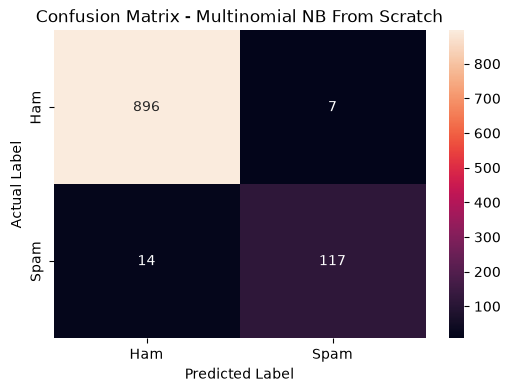

In [76]:
# Visualize the confusion matrix.
# Visualize the confusion matrix.
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Multinomial NB From Scratch")
plt.show()

## 19. Multinomial Naive Bayes Using Scikit-learn

Now we train Scikit-learn's `MultinomialNB` using the same word-count representation.

Using the same training and testing data makes the comparison with the from-scratch implementation fair.

## Multinomial Naive Bayes Using Scikit-learn

We now implement Multinomial Naive Bayes using Scikit-learn's
built-in MultinomialNB implementation.

The results will be compared with our from-scratch implementation.

In [77]:
# Train and use Scikit-learn's MultinomialNB on the same vectors.
from sklearn.naive_bayes import MultinomialNB

# Create Scikit-learn's Multinomial Naive Bayes model.
model_sklearn = MultinomialNB(alpha=1.0)

# Train the model using the same training word-count matrix.
model_sklearn.fit(X_train_vectors, y_train)

# Predict the test messages.
y_pred_sklearn = model_sklearn.predict(X_test_vectors)

print("First 20 Scikit-learn predictions:")
print(y_pred_sklearn[:20])

First 20 Scikit-learn predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [78]:
# Calculate classification metrics for the Scikit-learn model.
# Calculate metrics for the Scikit-learn model.
accuracy_sk = accuracy_score(y_test, y_pred_sklearn)

precision_sk = precision_score(y_test, y_pred_sklearn)

recall_sk = recall_score(y_test, y_pred_sklearn)

f1_sk = f1_score(y_test, y_pred_sklearn)

print("Multinomial NB - Scikit-learn")
print("--------------------------------")
print(f"Accuracy : {accuracy_sk:.4f}")
print(f"Precision: {precision_sk:.4f}")
print(f"Recall   : {recall_sk:.4f}")
print(f"F1 Score : {f1_sk:.4f}")

Multinomial NB - Scikit-learn
--------------------------------
Accuracy : 0.9797
Precision: 0.9435
Recall   : 0.8931
F1 Score : 0.9176


In [79]:
# Measure the percentage of identical predictions from both implementations.
# Check how many test predictions are identical
# between our implementation and Scikit-learn.
agreement = np.mean(
    y_pred_scratch == y_pred_sklearn
)

print(f"Prediction Agreement: {agreement * 100:.2f}%")

Prediction Agreement: 100.00%


## 20. From-Scratch vs Scikit-learn Comparison

Both implementations are evaluated on the same test data.

We compare:
- Accuracy
- Precision
- Recall
- F1 Score
- Prediction agreement

If the results are equal or very close, it provides evidence that the from-scratch implementation follows the same core Multinomial Naive Bayes calculations.

## Comparison: From Scratch vs Scikit-learn

The performance of our from-scratch Multinomial Naive Bayes
implementation is compared with Scikit-learn's implementation
using the same training and testing data.

In [80]:
# Create a metric-by-metric comparison table.
# ---------------------------------------------------------
# STEP 19: Compare Both Implementations
# ---------------------------------------------------------

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    
    "From Scratch": [
        accuracy,
        precision,
        recall,
        f1
    ],
    
    "Scikit-learn": [
        accuracy_sk,
        precision_sk,
        recall_sk,
        f1_sk
    ]
})

comparison

,Metric,From Scratch,Scikit-learn
0,Accuracy,0.979691,0.979691
1,Precision,0.943548,0.943548
2,Recall,0.893130,0.893130
3,F1 Score,0.917647,0.917647


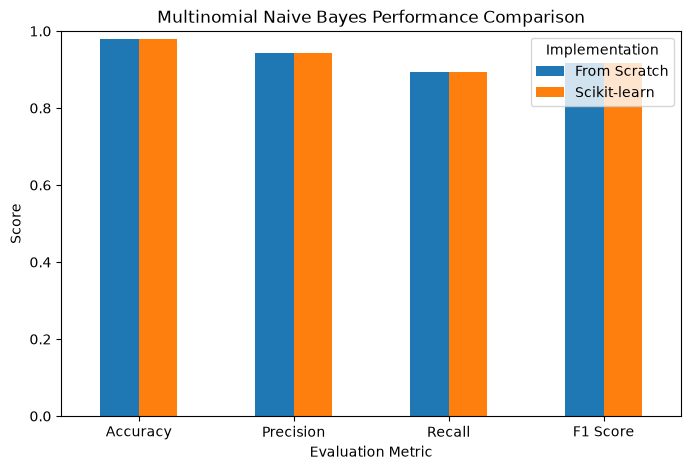

In [81]:
# Plot the evaluation metrics for both implementations.
# ---------------------------------------------------------
# STEP 20: Performance Comparison
# ---------------------------------------------------------

comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Multinomial Naive Bayes Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Implementation")
plt.show()

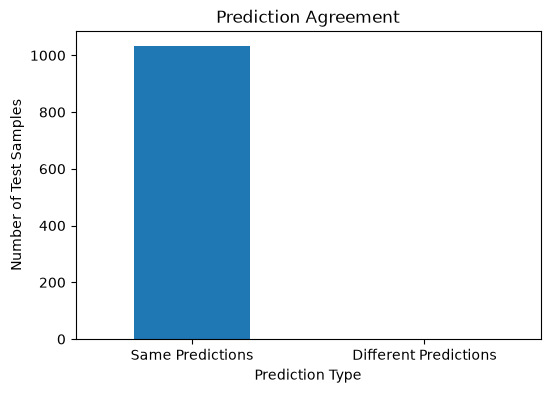

In [82]:
# Visualize how many predictions are the same or different.
# ---------------------------------------------------------
# STEP 21: Prediction Agreement
# ---------------------------------------------------------

agreement_data = pd.Series({
    "Same Predictions": np.sum(
        y_pred_scratch == y_pred_sklearn
    ),
    "Different Predictions": np.sum(
        y_pred_scratch != y_pred_sklearn
    )
})

agreement_data.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Prediction Agreement")
plt.xlabel("Prediction Type")
plt.ylabel("Number of Test Samples")
plt.xticks(rotation=0)
plt.show()

# 21. Multinomial Naive Bayes - Conclusion

Multinomial Naive Bayes was implemented from scratch using Python and NumPy on the SMS Spam Collection dataset.

The dataset was used for binary text classification:

- Ham → 0
- Spam → 1

The algorithm uses word-count features to calculate the probability of a message belonging to each class.

The from-scratch implementation was also compared with Scikit-learn's MultinomialNB model.

This comparison helps verify that the from-scratch implementation correctly follows the Multinomial Naive Bayes algorithm.

Overall, Multinomial Naive Bayes is a simple, fast, and effective algorithm for text classification problems, especially when word frequency is an important feature.

## 22. Time and Space Complexity

Let:

- `N` = number of training documents
- `D` = vocabulary size
- `C` = number of classes

### Training

Creating the document-term matrix requires processing the words in the training documents. The class-wise word-count calculations then operate over the vocabulary.

For the learned probability tables, the model stores one probability for each class-word pair:

**Space Complexity: O(C × D)**

### Prediction

For one document, the model evaluates the class score using the vocabulary features.

A straightforward dense implementation takes approximately:

**Time Complexity per document: O(C × D)**

For `T` test documents:

**Prediction Complexity: O(T × C × D)**

The actual runtime also depends on the number of words in the messages and the representation used.

# 23. Applications

Multinomial Naive Bayes can be used for:

- SMS spam detection
- Email spam filtering
- Sentiment analysis
- News article classification
- Document classification
- Text categorization
- Topic classification
- Basic natural language processing tasks

Multinomial Naive Bayes is particularly useful for text classification because it works well with **word-count or frequency-based features**.